# Homework

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [52]:
data = pd.read_csv('/home/log/homework/dataset/forest_dataset.csv')
data.head()

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2683,333,35,30,26,2743,121,173,179,6572,...,0,0,0,0,0,0,0,0,0,2
1,2915,90,8,216,11,4433,232,228,129,4019,...,0,0,0,0,0,0,0,0,0,1
2,2941,162,7,698,76,2783,227,242,148,1784,...,0,0,0,0,0,0,0,0,0,2
3,3096,60,17,170,3,3303,231,202,99,5370,...,0,0,0,0,0,0,0,0,0,1
4,2999,66,8,488,37,1532,228,225,131,2290,...,0,0,0,0,0,0,0,0,0,2


In [53]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The quality of classification/regression by the k Nearest Neighbors method depends on several parameters:
* the number of neighbors `n_neighbors`
* the distance metric between objects `metric`
* the weights of neighbors (the neighbors of the test example can enter with different weights, for example, the further the example, the less its "voice" is taken into account) `weights`


Train the `KNeighborsClassifier` on the dataset.

In [55]:
clf = KNeighborsClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Baseline accuracy:", accuracy_score(y_test, y_pred))

Baseline accuracy: 0.734


Let's select the parameters of our model:

* Iterate over the grid from `1` to `10` for the number of neighbors parameter
* Also, try using different metrics: `['manhattan', 'euclidean']`
* Try using different weight calculation strategies: `[‘uniform’, ‘distance’]`

In [56]:
params = {
    'n_neighbors': list(range(1, 11)),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}

clf = KNeighborsClassifier()

clf_grid = GridSearchCV(
    clf,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

clf_grid.fit(X_train, y_train)

print("Best params:", clf_grid.best_params_)

Best params: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}


Using the optimal number of neighbors found, calculate the probabilities of belonging to classes for the test sample (`.predict_proba`).

In [57]:
optimal_clf = KNeighborsClassifier(**clf_grid.best_params_)
optimal_clf.fit(X_train, y_train)

y_pred = optimal_clf.predict(X_test)
print("Final accuracy:", accuracy_score(y_test, y_pred))
pred_prob = optimal_clf.predict_proba(X_test)

Final accuracy: 0.758


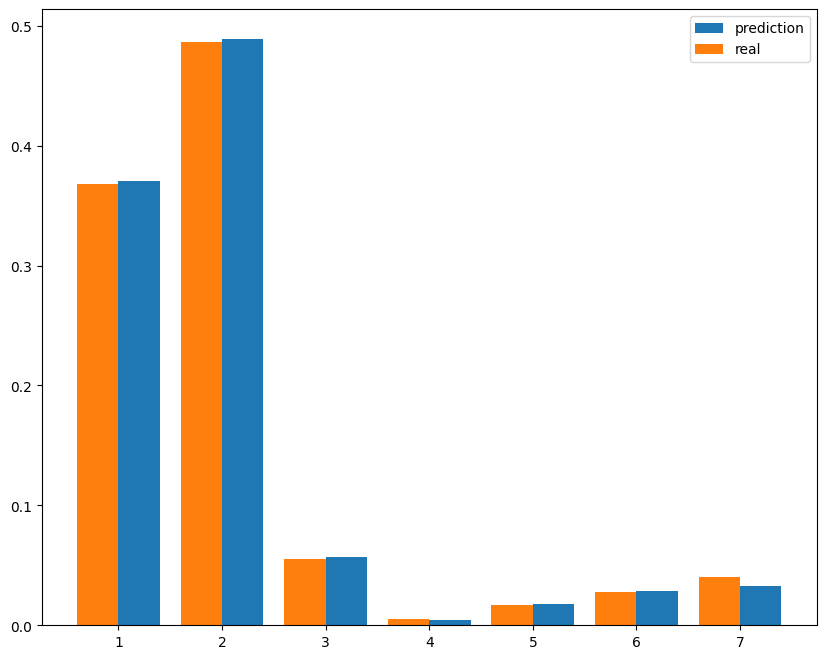

In [61]:
unique, freq = np.unique(y_test, return_counts=True)
freq = freq / len(y_test)

pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(unique, pred_freq, width=0.4, align="edge", label='prediction')
plt.bar(unique, freq, width=-0.4, align="edge", label='real')
plt.legend()
plt.show()

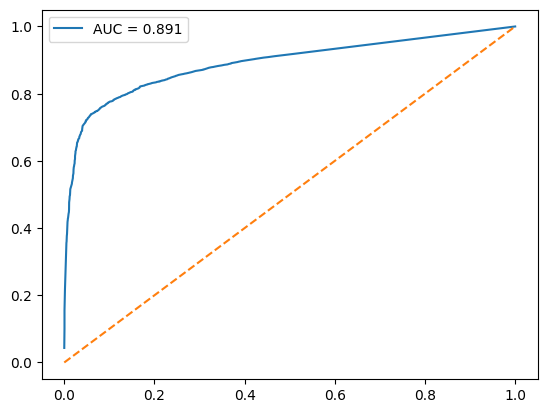

AUC-ROC: 0.8905270443948636


In [64]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

fpr = dict()
tpr = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred_prob[:, i])

# усреднение
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(len(classes)):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= len(classes)
roc_auc_macro = auc(all_fpr, mean_tpr)

plt.plot(all_fpr, mean_tpr, label=f"AUC = {roc_auc_macro:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.legend()
plt.show()

print("AUC-ROC:", roc_auc_macro)

## Логистиеская регрессия

In [66]:
from sklearn.linear_model import LogisticRegression

# важно: логистической регрессии тоже нужна нормализация!
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_clf = LogisticRegression(max_iter=1000)
log_clf.fit(X_train_scaled, y_train)

y_pred_log = log_clf.predict(X_test_scaled)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_log))

pred_prob_log = log_clf.predict_proba(X_test_scaled)

Logistic Regression accuracy: 0.718


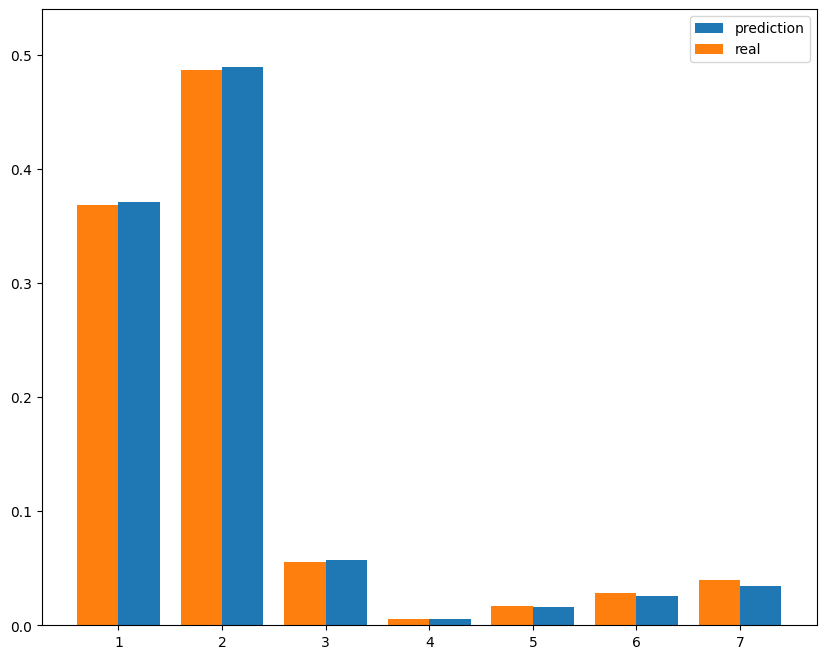

In [71]:
unique, freq = np.unique(y_test, return_counts=True)
freq = freq / len(y_test)

pred_freq = pred_prob_log.mean(axis=0)  # для логистической регрессии

plt.figure(figsize=(10, 8))
plt.bar(unique, pred_freq, width=0.4, align="edge", label='prediction')
plt.bar(unique, freq, width=-0.4, align="edge", label='real')
plt.ylim(0, 0.54)
plt.legend()
plt.show()

### ROC

In [68]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

fpr_log = dict()
tpr_log = dict()

for i in range(len(classes)):
    fpr_log[i], tpr_log[i], _ = roc_curve(y_test_bin[:, i], pred_prob_log[:, i])

# усреднение
all_fpr_log = np.unique(np.concatenate([fpr_log[i] for i in range(len(classes))]))
mean_tpr_log = np.zeros_like(all_fpr_log)

for i in range(len(classes)):
    mean_tpr_log += np.interp(all_fpr_log, fpr_log[i], tpr_log[i])

mean_tpr_log /= len(classes)
roc_auc_log = auc(all_fpr_log, mean_tpr_log)

print("Logistic Regression AUC-ROC:", roc_auc_log)

Logistic Regression AUC-ROC: 0.937123889266955


## Сравнеие логистической регрессии с knn

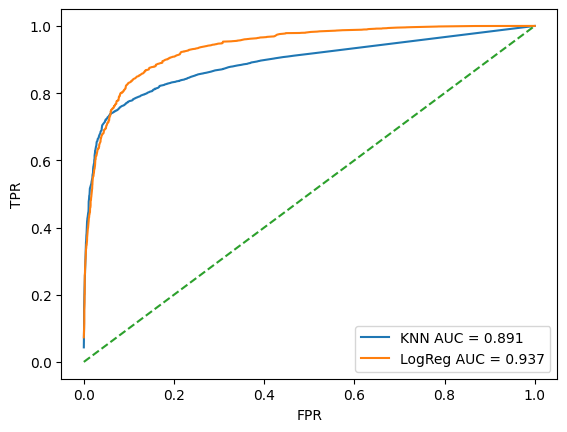

In [70]:
plt.plot(all_fpr, mean_tpr, label=f"KNN AUC = {roc_auc_macro:.3f}")
plt.plot(all_fpr_log, mean_tpr_log, label=f"LogReg AUC = {roc_auc_log:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

## Conclusion

What is the quality of the model on the test sample? Compare it with the quality of logistic regression. Which model is better? Why? What are the pros and cons of the k Nearest Neighbors method? Plot the ROC curve for the k Nearest Neighbors method. Calculate the area under the ROC curve (AUC-ROC).

На тестовой выборке были получены следующие результаты:

KNN:
Accuracy =  0.758
AUC-ROC = 0.8905270443948636

Логистическая регрессия:
Accuracy = 0.718
AUC-ROC = 0.937123889266955

Хотя KNN точнее по количеству верных предсказаний, логистическая регрессия лучше оценивает вероятности классов (AUC выше).

Вывод:

KNN быстрее на небольших данных, хорошо учитывает сложные границы, но чувствителен к масштабам признаков.
Логистическая регрессия стабильнее, особенно для вероятностной оценки, и в данном случае показывает лучший AUC.